# EDA + Boosting model

In [38]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib

In [39]:
# Definir ruta donde estan los archivos
path = r'../data/raw/'

In [40]:
# Listar archivos Parquet que comienzan con 'data'
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [41]:
# Leer cada archivo Parquet y almacenarlo en una lista de DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [42]:
# Concatenar todos los DataFrames en un único DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

In [43]:
# Convertimos Date a datetime (necesario para split temporal)
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\USER\AppData\Local\Temp\ipykernel_8404\1063807796.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


## Ingenieria de caracteristicas

In [44]:
def rsi_strength(rsi):
    if rsi < 40:
        return 0   # Débil
    elif rsi <= 60:
        return 1   # Neutral
    else:
        return 2   # Fuerte

df['rsi_strength'] = df['RSI'].apply(rsi_strength)

In [45]:
v1 = df['Volatility'].quantile(0.33)
v2 = df['Volatility'].quantile(0.66)

def vol_level(v):
    if v < v1:
        return 0   # Baja
    elif v < v2:
        return 1   # Media
    else:
        return 2   # Alta

df['vol_level'] = df['Volatility'].apply(vol_level)

In [46]:
# target = 1 si Future_Return_10d >= 2%
# target = 0 si Future_Return_10d <= 0%
df['target'] = np.nan

df.loc[df['Future_Return_10d'] >= 0.02, 'target'] = 1
df.loc[df['Future_Return_10d'] <= 0.0, 'target'] = 0

df = df.dropna(subset=['target'])

In [47]:
df['price_vs_sma20'] = (df['Close'] / df['SMA_20']) - 1

In [48]:
# Columnas que queremos mantener
cols_to_keep = ['Date', 'Price_Change_5d', 'price_vs_sma20', 'rsi_strength', 'Volume_Ratio', 'vol_level', 'target']

existing_cols = [c for c in cols_to_keep if c in df.columns]
df = df[existing_cols]

In [49]:
# Show final columns
df.columns

Index(['Date', 'Price_Change_5d', 'price_vs_sma20', 'rsi_strength',
       'Volume_Ratio', 'vol_level', 'target'],
      dtype='object')

## Split Temporal

In [50]:
# Ordenamos justo antes del split
df = df.sort_values('Date').reset_index(drop=True)

In [51]:
# Definimos fecha de corte (80% más antiguo para train)
split_index = int(len(df) * 0.8)

In [52]:
# Creamos datasets temporales
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

In [53]:
# Definimos X, y, y eliminamos Date
X_train = train_df.drop(columns=['target', 'Date'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target', 'Date'])
y_test = test_df['target']

## Standard Scaler

In [54]:
# Escalado Estándar para todas las variables (X)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

## Creating model and training data - XGBoost

In [55]:
# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train_scaled, y_train.values.ravel())

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Predictions

In [56]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [57]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [58]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.5534779858542102,
 0.5520018232925625,
 0.15150125104253545,
 0.2377501104330612,
 0.5319136475334213)

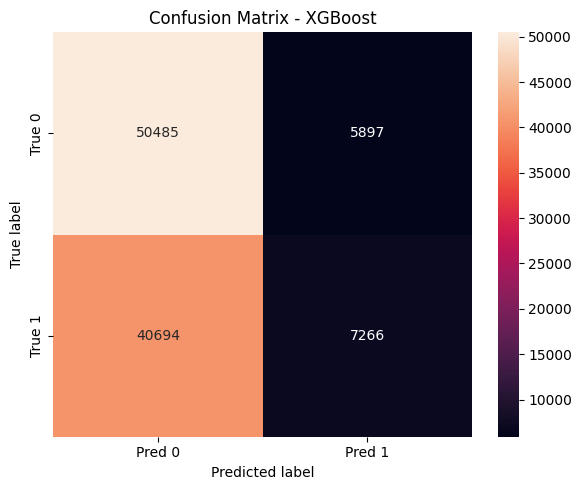

In [59]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt="d", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])

plt.title("Confusion Matrix - XGBoost")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [60]:
# Classification report
classification_report(y_test, y_pred, digits=3)

'              precision    recall  f1-score   support\n\n         0.0      0.554     0.895     0.684     56382\n         1.0      0.552     0.152     0.238     47960\n\n    accuracy                          0.553    104342\n   macro avg      0.553     0.523     0.461    104342\nweighted avg      0.553     0.553     0.479    104342\n'

## Optimization

In [61]:
# Hyperparameters to test
hyperparams = {"n_estimators" : [100, 200],
               "learning_rate" : [0.05, 0.1],
               "max_depth" : [2, 3, 4],
               "min_split_loss" : [0, 0.1],
               "subsample" : [0.7, 0.8],
               "colsample_bytree" : [0.7, 0.8]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search = GridSearchCV(xgb_model, hyperparams, scoring="roc_auc", cv=tscv, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train.values.ravel())

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_split_loss': [0, 0.1], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [62]:
# Best parameters and evaluation
grid_model_xgb = grid_search.best_estimator_

y_pred_opt = grid_model_xgb.predict(X_test_scaled)
y_proba_opt = grid_model_xgb.predict_proba(X_test_scaled)[:,1]

In [63]:
# Metrics for optimized model
test_accuracy = accuracy_score(y_test, y_pred_opt)
test_precision = precision_score(y_test, y_pred_opt)
test_recall = recall_score(y_test, y_pred_opt)
test_f1 = f1_score(y_test, y_pred_opt)
test_roc_auc = roc_auc_score(y_test, y_proba_opt)

In [64]:
# Showing results
test_accuracy, test_precision, test_recall, test_f1, test_roc_auc

(0.5520595733261774,
 0.5466350928118555,
 0.14920767306088406,
 0.2344269545134396,
 0.5305138594383381)

## Creating model and training data - Gradient Boosting

In [65]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)

# Train the model
gb_model.fit(X_train_scaled, y_train.values.ravel())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Predictions

In [66]:
# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test_scaled)
y_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

In [67]:
# Evaluate accuracy and other metrics
model_accuracy_gb = accuracy_score(y_test, y_pred_gb)
model_precision_gb = precision_score(y_test, y_pred_gb)
model_recall_gb = recall_score(y_test, y_pred_gb)
model_f1_gb = f1_score(y_test, y_pred_gb)
model_roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

In [68]:
# Showing results
model_accuracy_gb, model_precision_gb, model_recall_gb, model_f1_gb, model_roc_auc_gb

(0.5544172049606103,
 0.5592440029076812,
 0.14437030859049207,
 0.22949569944150744,
 0.532024761080357)

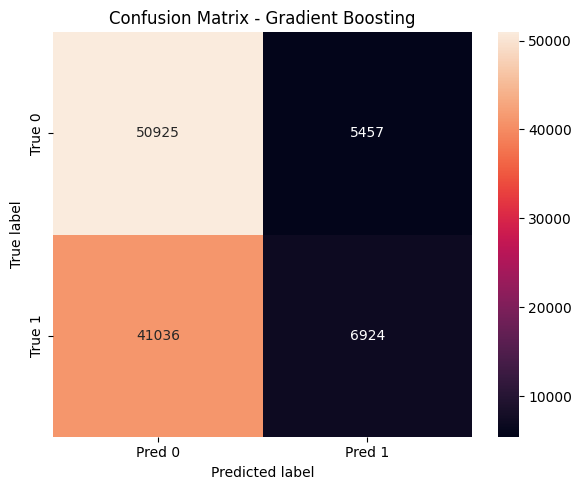

In [69]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt="d", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])

plt.title("Confusion Matrix - Gradient Boosting")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [70]:
# Classification report
classification_report(y_test, y_pred_gb, digits=3)

'              precision    recall  f1-score   support\n\n         0.0      0.554     0.903     0.687     56382\n         1.0      0.559     0.144     0.229     47960\n\n    accuracy                          0.554    104342\n   macro avg      0.557     0.524     0.458    104342\nweighted avg      0.556     0.554     0.476    104342\n'

## Optimization

In [71]:
# Hyperparameters to test
hyperparams_gb = {"n_estimators" : [100, 200],
                  "learning_rate" : [0.05, 0.1],
                  "max_depth" : [2, 3, 4],
                  "subsample" : [0.7, 0.8],
                  "max_features" : ["sqrt", "log2"]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search_gb = GridSearchCV(gb_model, hyperparams_gb, scoring="roc_auc", cv=tscv, n_jobs=-1)
grid_search_gb.fit(X_train_scaled, y_train.values.ravel())

,estimator,GradientBoost...subsample=0.8)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [72]:
# Best parameters and evaluation
grid_model_gb = grid_search_gb.best_estimator_

y_pred_gb_opt = grid_model_gb.predict(X_test_scaled)
y_proba_gb_opt = grid_model_gb.predict_proba(X_test_scaled)[:,1]

In [73]:
# Metrics for optimized model
test_accuracy_gb = accuracy_score(y_test, y_pred_gb_opt)
test_precision_gb = precision_score(y_test, y_pred_gb_opt)
test_recall_gb = recall_score(y_test, y_pred_gb_opt)
test_f1_gb = f1_score(y_test, y_pred_gb_opt)
test_roc_auc_gb = roc_auc_score(y_test, y_proba_gb_opt)

In [74]:
# Showing results
test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb, test_roc_auc_gb

(0.5526058538268387,
 0.5469714789767716,
 0.15515012510425355,
 0.2417321811448249,
 0.5304166587527017)

In [76]:
# Saving best model
joblib.dump(gb_model, "../models/gb-model-target10.pkl")

['../models/gb-model-target10.pkl']